In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/energy_data.csv")

df.columns = df.columns.str.strip()

df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])

# Set as index
df.set_index(df.columns[0], inplace=True)

df.head()

,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01 00:00:00,119,0,73,0,192
2023-01-01 01:00:00,134,0,0,0,134
2023-01-01 02:00:00,0,1551,73,0,1624
2023-01-01 03:00:00,0,0,66,0,66
2023-01-01 04:00:00,83,0,86,0,169


In [6]:
monthly = df['total_power'].resample('M').sum()

monthly

C:\Users\DELL\AppData\Local\Temp\ipykernel_17212\530972294.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['total_power'].resample('M').sum()


timestamp
2023-01-31     291127
2023-02-28     276913
2023-03-31     303217
2023-04-30    1153867
2023-05-31    1230662
2023-06-30    1131343
Freq: ME, Name: total_power, dtype: int64

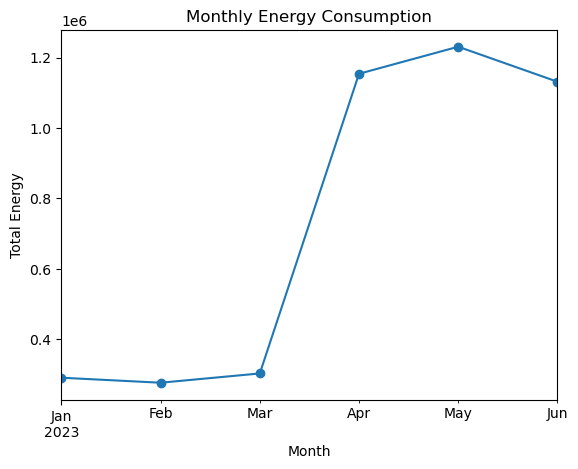

In [7]:
monthly.plot(marker='o')
plt.title("Monthly Energy Consumption")
plt.ylabel("Total Energy")
plt.xlabel("Month")
plt.show()

In [8]:
growth = monthly.pct_change() * 100
growth

timestamp
2023-01-31           NaN
2023-02-28     -4.882405
2023-03-31      9.499012
2023-04-30    280.541658
2023-05-31      6.655446
2023-06-30     -8.070372
Freq: ME, Name: total_power, dtype: float64

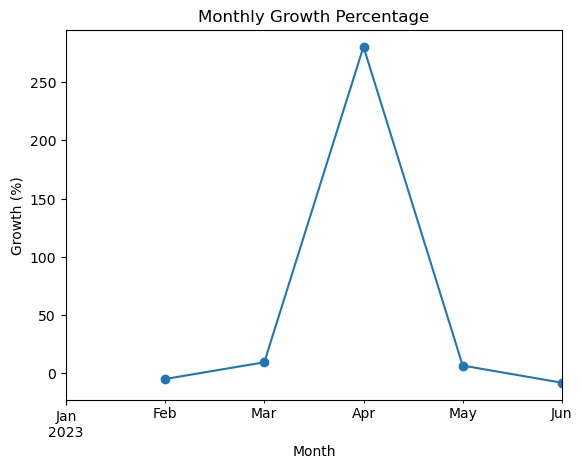

In [9]:
growth.plot(marker='o')
plt.title("Monthly Growth Percentage")
plt.ylabel("Growth (%)")
plt.xlabel("Month")
plt.show()

In [10]:
df['month'] = df.index.month

monthly_avg = df.groupby('month')['total_power'].mean()

monthly_avg

month
1     391.299731
2     412.072917
3     407.549731
4    1602.593056
5    1654.115591
6    1623.160689
Name: total_power, dtype: float64

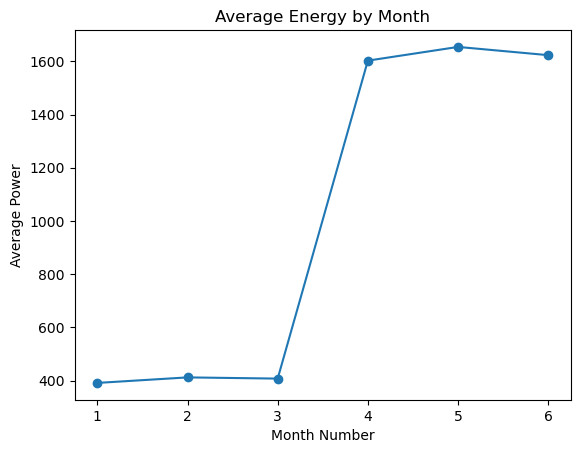

In [11]:
monthly_avg.plot(marker='o')
plt.title("Average Energy by Month")
plt.ylabel("Average Power")
plt.xlabel("Month Number")
plt.show()